# Legal Text Classification & Summarization
## NLP Minor Project — ECtHR (European Court of Human Rights) Dataset

### Project Overview
This notebook covers:
1. **Dataset Loading** — ECtHR NAACL 2021 via KaggleHub
2. **Exploratory Data Analysis (EDA)**
3. **Text Preprocessing** — Tokenization, Stopword Removal, Lemmatization
4. **Feature Extraction** — TF-IDF, BoW
5. **Text Classification** — Logistic Regression, SVM, Naive Bayes
6. **Text Summarization** — TextRank (Extractive)
7. **Evaluation** — Accuracy, F1-Score, ROUGE

---
## Section 1: Install Dependencies

In [ ]:
!pip install kagglehub nltk scikit-learn sumy rouge-score pandas matplotlib seaborn wordcloud -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 28.7 MB/s eta 0:00:00


---
## Section 2: Load Dataset
This code downloads the ECtHR NAACL 2021 dataset from Kaggle using the kagglehub library. It then prints the dataset path and lists all files in the directory to verify that the dataset has been downloaded successfully.


In [ ]:
import kagglehub
import os
import json
import pandas as pd

path = kagglehub.dataset_download("mathurinache/ecthrnaacl2021")
print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 32.0M/32.0M [00:00<00:00, 82.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1
/root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1/train.jsonl
/root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1/dev.jsonl
/root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1/test.jsonl


This code defines a function **load_jsonl()** to read JSONL files and convert them into a pandas DataFrame for easier data processing. It then identifies the paths for the train, test, and validation datasets within the downloaded ECtHR dataset. Using the **glob** library, the code searches through the dataset directories to locate files containing train, test, and development data and prints their file paths for verification.


In [ ]:
def load_jsonl(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                records.append(json.loads(line.strip()))
            except:
                pass
    return pd.DataFrame(records)

train_path = os.path.join(path, 'EN_train', 'EN_train')
test_path  = os.path.join(path, 'EN_test',  'EN_test')
dev_path   = os.path.join(path, 'EN_dev',   'EN_dev')

import glob
train_files = glob.glob(path + '/**/*train*', recursive=True)
test_files  = glob.glob(path + '/**/*test*',  recursive=True)
dev_files   = glob.glob(path + '/**/*dev*',   recursive=True)

print('Train files:', train_files)
print('Test files:', test_files)
print('Dev files:', dev_files)

Train files: ['/root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1/train.jsonl']
Test files: ['/root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1/test.jsonl']
Dev files: ['/root/.cache/kagglehub/datasets/mathurinache/ecthrnaacl2021/versions/1/dev.jsonl']


This code loads the training, testing, and validation datasets using the **load_jsonl()** function and stores them in separate DataFrames. It then prints the shape of each dataset to show the number of rows and columns. Finally, it displays the first few rows of the training dataset to preview the data.


In [ ]:
df_train = load_jsonl(train_files[0])
df_test  = load_jsonl(test_files[0])
df_dev   = load_jsonl(dev_files[0])

print(f"Train: {df_train.shape} | Test: {df_test.shape} | Dev: {df_dev.shape}")
df_train.head(3)

Train: (9000, 12) | Test: (1000, 12) | Dev: (1000, 12)


,case_id,case_no,title,judgment_date,facts,applicants,defendants,allegedly_violated_articles,violated_articles,court_assessment_references,silver_rationales,gold_rationales
0,001-59587,25702/94,CASE OF K. AND T. v. FINLAND,2001-07-12,[11. At the beginning of the events relevant ...,"[K., T.]",[FINLAND],"[13, 8]",[8],"{'8': ['12', '140', '155', '156', '157', '158'...","[1, 13, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30...",[]
1,001-59591,42527/98,CASE OF PRINCE HANS-ADAM II OF LIECHTENSTEIN v...,2001-07-12,[9. The applicant is the monarch of Liechtens...,[PRINCE HANS-ADAM II OF LIECHTENSTEIN],[GERMANY],"[14, P1-1, 6]",[],"{'6': ['12', '15', '24', '25', '26', '27', '28...","[3, 6]",[]
2,001-59590,33071/96,CASE OF MALHOUS v. THE CZECH REPUBLIC,2001-07-12,[9. In June 1949 plots of agricultural land o...,[MALHOUS],[CZECH REPUBLIC],[6],[6],"{'6': ['13', '14', '35', '40', '41', '42', '43...","[4, 5]",[]


---
## Section 3: Exploratory Data Analysis (EDA)

This code imports visualization libraries **Matplotlib** and **Seaborn**, along with **Counter** for analyzing label frequency. It then prints the column names of the training dataset and displays a sample record to understand the structure and contents of the data.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Columns:", df_train.columns.tolist())
print("\nSample record:")
print(df_train.iloc[0])

Columns: ['case_id', 'case_no', 'title', 'judgment_date', 'facts', 'applicants', 'defendants', 'allegedly_violated_articles', 'violated_articles', 'court_assessment_references', 'silver_rationales', 'gold_rationales']

Sample record:
case_id                                                                001-59587
case_no                                                                 25702/94
title                                               CASE OF K. AND T. v. FINLAND
judgment_date                                                         2001-07-12
facts                          [11.  At the beginning of the events relevant ...
applicants                                                              [K., T.]
defendants                                                             [FINLAND]
allegedly_violated_articles                                              [13, 8]
violated_articles                                                            [8]
court_assessment_references    {'8': 

This code combines the paragraphs in the **facts** column into a single text string for each case. It then calculates the length of each text and stores it in a new column called **text_length**. Finally, a histogram is plotted to visualize the distribution of text lengths in the training dataset.


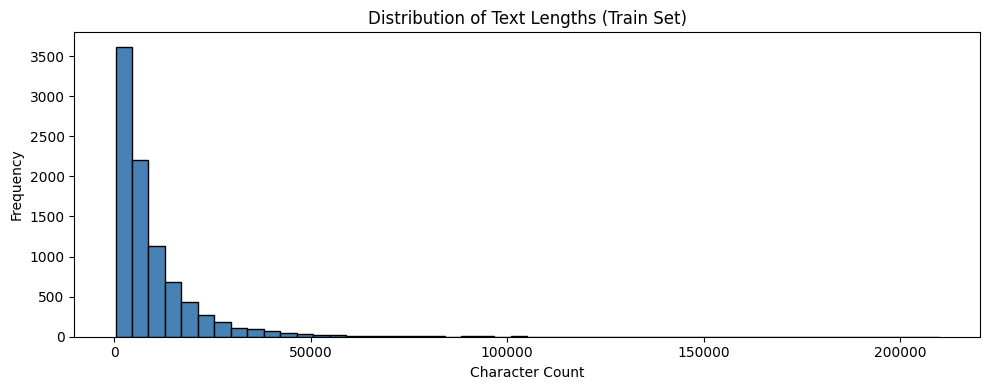

In [ ]:
  df_train['text'] = df_train['facts'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
  df_test['text']  = df_test['facts'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
  df_dev['text']   = df_dev['facts'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

  df_train['text_length'] = df_train['text'].apply(len)
  plt.figure(figsize=(10, 4))
  plt.hist(df_train['text_length'], bins=50, color='steelblue', edgecolor='black')
  plt.title('Distribution of Text Lengths (Train Set)')
  plt.xlabel('Character Count')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

This code analyzes the **violated_articles** column to understand the distribution of legal article labels in the training dataset. It counts how frequently each article appears using the **Counter** function. The top 20 most frequent violated articles are then selected and visualized using a bar chart to show their occurrence in the dataset.


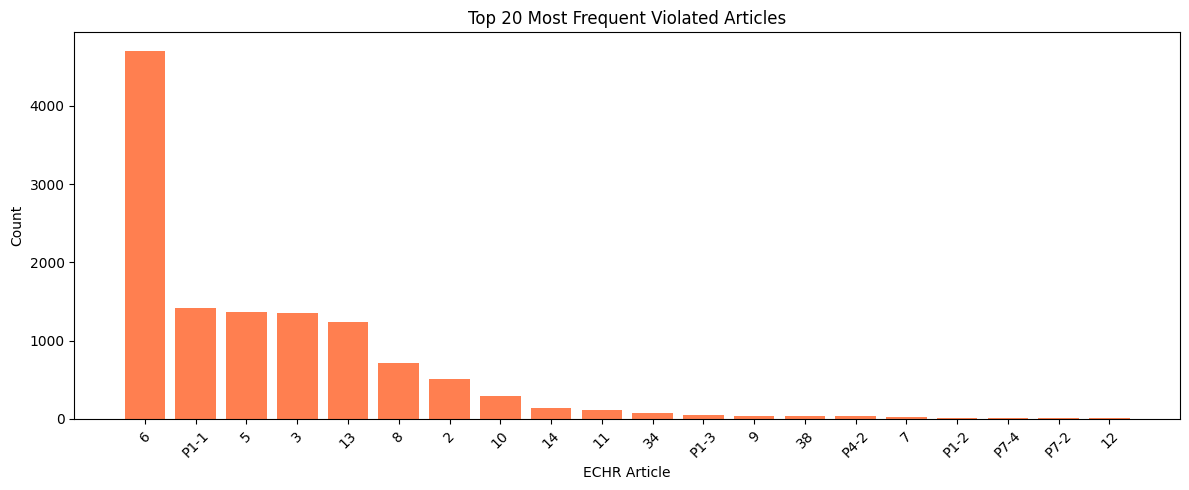

In [ ]:
label_col = 'violated_articles'

all_labels = [label for sublist in df_train[label_col] for label in sublist]
label_counts = Counter(all_labels)

top_labels = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:20])

plt.figure(figsize=(12, 5))
plt.bar(top_labels.keys(), top_labels.values(), color='coral')
plt.title('Top 20 Most Frequent Violated Articles')
plt.xlabel('ECHR Article')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code generates a **word cloud** from the legal case texts to visualize the most frequently occurring words. A subset of the training data is used for faster processing. The WordCloud library creates a visual representation where frequently appearing words are displayed more prominently, helping understand common terms used in legal case descriptions.


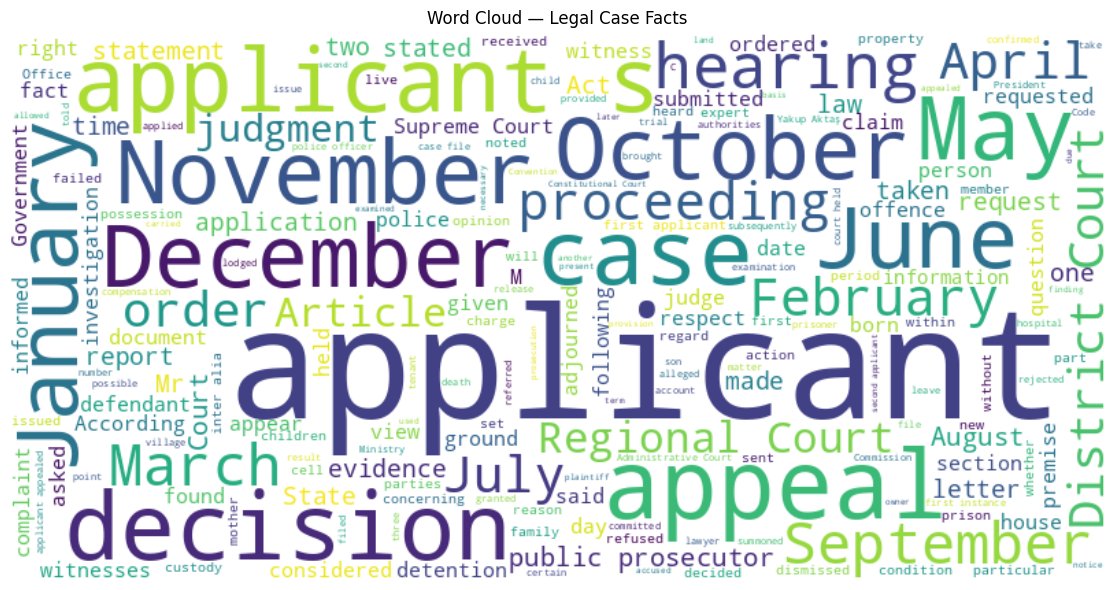

In [ ]:
from wordcloud import WordCloud

all_text = ' '.join(df_train['text'].tolist()[:500])  # use subset for speed
wc = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Legal Case Facts')
plt.tight_layout()
plt.show()

---
## Section 4: Text Preprocessing

This code performs **text preprocessing** on the legal case documents using the NLTK library. It converts text to lowercase, removes special characters, tokenizes the text into words, removes stopwords, and applies lemmatization to reduce words to their base form. The cleaned text is stored in a new column called **clean_text**, which is used for further NLP processing and model training.


In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing texts... (this may take a minute)")
df_train['clean_text'] = df_train['text'].apply(preprocess_text)
df_test['clean_text']  = df_test['text'].apply(preprocess_text)
df_dev['clean_text']   = df_dev['text'].apply(preprocess_text)

print("Done! Sample:")
print(df_train['clean_text'].iloc[0][:300])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing texts... (this may take a minute)
Done! Sample:
beginning event relevant application daughter son born respectively father father march may voluntarily hospitalised three month diagnosed suffering schizophrenia august november december march hospitalised period three month account illness hospitalised less week diagnosed suffering atypical undefi


---
## Section 5: Label Encoding (for Classification)

This code converts the **multi-label article data** into a numerical format using **MultiLabelBinarizer** from scikit-learn. Each violated article is transformed into a binary vector indicating whether the article is present or not. The transformed labels are stored in **y_train** and **y_test**, and the code prints the label classes along with the shapes of the resulting matrices.



In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform(df_train[label_col])
y_test  = mlb.transform(df_test[label_col])

print("Label classes:", mlb.classes_)
print("\ny_train shape:", y_train.shape)
print("y_test shape:",  y_test.shape)

Label classes: ['10' '11' '12' '13' '14' '18' '2' '3' '34' '38' '4' '46' '5' '6' '7' '8'
 '9' 'P1-1' 'P1-2' 'P1-3' 'P12-1' 'P4-2' 'P4-4' 'P6-1' 'P6-3' 'P7-1'
 'P7-2' 'P7-3' 'P7-4']

y_train shape: (9000, 29)
y_test shape: (1000, 29)


---
## Section 6: Feature Extraction — TF-IDF

This code converts the cleaned legal text into numerical feature vectors using the **TF-IDF (Term Frequency–Inverse Document Frequency)** technique. It considers up to 10,000 features and includes both unigrams and bigrams. The vectorizer is fitted on the training data and then used to transform both training and test datasets into TF-IDF matrices for model training.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(df_train['clean_text'])
X_test_tfidf  = tfidf.transform(df_test['clean_text'])

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape:",  X_test_tfidf.shape)

TF-IDF Train shape: (9000, 10000)
TF-IDF Test shape: (1000, 10000)


---
## Section 7: Multi-Label Text Classification

This code trains a **Logistic Regression model** for multi-label classification using the **One-vs-Rest strategy**. The model is trained on the TF-IDF feature vectors of the training dataset. After training, it predicts the violated articles for the test data. Finally, the model performance is evaluated using **Micro F1-score and Macro F1-score**, which measure the classification accuracy across all labels.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score

print("Training Logistic Regression...")
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=500, C=1.0))
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("\n📊 Logistic Regression Results:")
print(f"  Micro F1 : {f1_score(y_test, y_pred_lr, average='micro'):.4f}")
print(f"  Macro F1 : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

Training Logistic Regression...

📊 Logistic Regression Results:
  Micro F1 : 0.6051
  Macro F1 : 0.1517


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import LinearSVC

print("Training SVM...")
svm_model = OneVsRestClassifier(LinearSVC(max_iter=1000))
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("\n📊 SVM Results:")
print(f"  Micro F1 : {f1_score(y_test, y_pred_svm, average='micro'):.4f}")
print(f"  Macro F1 : {f1_score(y_test, y_pred_svm, average='macro'):.4f}")

Training SVM...

📊 SVM Results:
  Micro F1 : 0.6592
  Macro F1 : 0.2463


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This code trains a **Support Vector Machine (SVM)** model using the **One-vs-Rest classification strategy** for multi-label prediction. The model uses **class_weight='balanced'** to handle class imbalance in the dataset. After training on the TF-IDF features, the model predicts the violated articles for the test data. The performance is evaluated using **Micro F1-score, Macro F1-score, Samples F1-score, and Hamming Loss**.


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import hamming_loss

print('Training SVM Balanced...')
svm_bal = OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=1.0, class_weight='balanced')
)
svm_bal.fit(X_train_tfidf, y_train)
y_pred_bal = svm_bal.predict(X_test_tfidf)

print('\n📊 SVM Balanced (class_weight="balanced"):')
print(f'  Micro F1   : {f1_score(y_test, y_pred_bal, average="micro",   zero_division=0):.4f}')
print(f'  Macro F1   : {f1_score(y_test, y_pred_bal, average="macro",   zero_division=0):.4f}')
print(f'  Samples F1 : {f1_score(y_test, y_pred_bal, average="samples", zero_division=0):.4f}')
print(f'  Hamming ↓  : {hamming_loss(y_test, y_pred_bal):.4f}')

Training SVM Balanced...


This code trains a **Naive Bayes classifier** using the **One-vs-Rest strategy** for multi-label classification. The model is trained on the TF-IDF features of the training dataset. After training, it predicts the violated articles for the test data and evaluates the performance using **Micro F1-score and Macro F1-score**.


In [ ]:
from sklearn.naive_bayes import MultinomialNB

print("Training Naive Bayes...")
nb_model = OneVsRestClassifier(MultinomialNB())
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("\n📊 Naive Bayes Results:")
print(f"  Micro F1 : {f1_score(y_test, y_pred_nb, average='micro'):.4f}")
print(f"  Macro F1 : {f1_score(y_test, y_pred_nb, average='macro'):.4f}")

Training Naive Bayes...

📊 Naive Bayes Results:
  Micro F1 : 0.5583
  Macro F1 : 0.1356


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This code compares the performance of **Logistic Regression, SVM, and Naive Bayes** models using **Micro F1 and Macro F1 scores**. The scores are calculated for each model and stored in lists. A bar chart is then created to visually compare the performance of the models, helping identify which algorithm performs best for the multi-label classification task.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


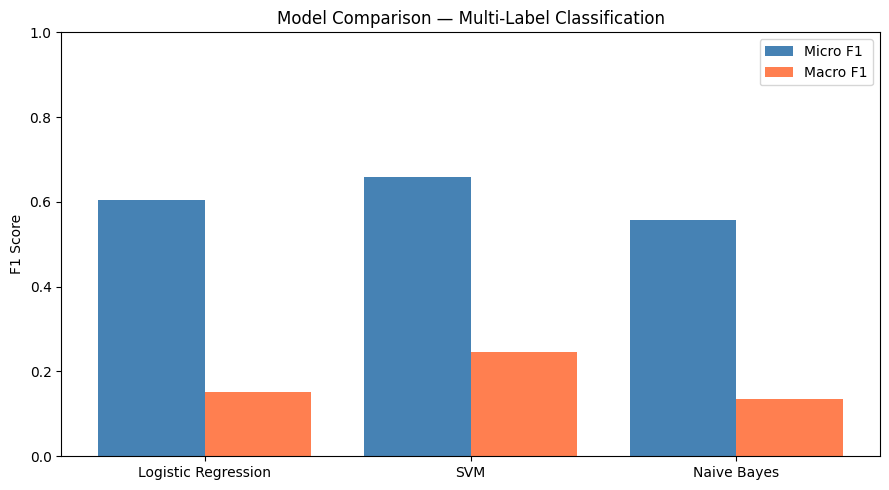

In [ ]:

models     = ['Logistic Regression', 'SVM', 'Naive Bayes']
micro_f1   = [
    f1_score(y_test, y_pred_lr,  average='micro'),
    f1_score(y_test, y_pred_svm, average='micro'),
    f1_score(y_test, y_pred_nb,  average='micro')
]
macro_f1   = [
    f1_score(y_test, y_pred_lr,  average='macro'),
    f1_score(y_test, y_pred_svm, average='macro'),
    f1_score(y_test, y_pred_nb,  average='macro')
]

x = range(len(models))
plt.figure(figsize=(9, 5))
plt.bar([i - 0.2 for i in x], micro_f1, width=0.4, label='Micro F1', color='steelblue')
plt.bar([i + 0.2 for i in x], macro_f1, width=0.4, label='Macro F1', color='coral')
plt.xticks(x, models)
plt.ylabel('F1 Score')
plt.title('Model Comparison — Multi-Label Classification')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

---
## Section 8: Extractive Text Summarization (TextRank)

This code implements **extractive text summarization** using the **Sumy library**. It defines a function that generates summaries using three algorithms: **TextRank, Latent Semantic Analysis (LSA), and Luhn**. The function selects a specified number of important sentences from the original text. A sample legal case from the test dataset is then summarized using all three methods to compare their outputs.


In [ ]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.summarizers.lsa import LsaSummarizer
from sumy.summarizers.luhn import LuhnSummarizer

def summarize_text(text, summarizer_type='textrank', num_sentences=3):
    """Summarize text using specified algorithm."""
    parser = PlaintextParser.from_string(text, Tokenizer('english'))

    if summarizer_type == 'textrank':
        summarizer = TextRankSummarizer()
    elif summarizer_type == 'lsa':
        summarizer = LsaSummarizer()
    elif summarizer_type == 'luhn':
        summarizer = LuhnSummarizer()

    summary = summarizer(parser.document, num_sentences)
    return ' '.join(str(s) for s in summary)


sample_text = df_test['text'].iloc[0]
print("=" * 60)
print("ORIGINAL TEXT (first 500 chars):")
print(sample_text[:500])
print("\n" + "=" * 60)
print("TEXTRANK SUMMARY:")
print(summarize_text(sample_text, 'textrank', 3))
print("\n" + "=" * 60)
print("LSA SUMMARY:")
print(summarize_text(sample_text, 'lsa', 3))
print("\n" + "=" * 60)
print("LUHN SUMMARY:")
print(summarize_text(sample_text, 'luhn', 3))

ORIGINAL TEXT (first 500 chars):
5.  The applicant is a journalist for DN.no, a Norwegian Internet-based version of the newspaper Dagens Næringsliv (“DN”), published by the company DN Nye Medier AS. 6.  On 23 June 2010 Mr X was indicted for market manipulation and insider trading under the 1997 Act on the Trade of Financial Assets (verdipapirhandelloven). He was accused of having requested Mr Y, an attorney, to draft a letter concerning the Norwegian Oil Company (“DNO”), a limited liability company quoted on the stock exchange.

TEXTRANK SUMMARY:
In the court records (“rettsboken”), his arguments in favour of issuing such an order are restated as having included the following: “The prosecutor rose to speak and argued that the witness had an obligation to give testimony about her contact with the defendant in connection with the letter to [the bond trustee company] of 24 August 2007 and asked the court to make a decision on the matter. In determining whether a legitimate interest in a d

---
##  Section 9: Summarization Evaluation (ROUGE Score)

This code evaluates the performance of the summarization algorithms using **ROUGE metrics**. It calculates **ROUGE-1, ROUGE-2, and ROUGE-L scores** by comparing the generated summaries with reference text from the original document. The evaluation is performed on a sample of the test dataset. Finally, the results for **TextRank, LSA, and Luhn** summarizers are displayed and visualized using a bar chart for comparison.


Evaluating summarizers (50 samples)...
TEXTRANK   → {'ROUGE-1': 0.1134, 'ROUGE-2': 0.032, 'ROUGE-L': 0.0878}
LSA        → {'ROUGE-1': 0.1546, 'ROUGE-2': 0.035, 'ROUGE-L': 0.1188}
LUHN       → {'ROUGE-1': 0.1166, 'ROUGE-2': 0.0328, 'ROUGE-L': 0.0893}


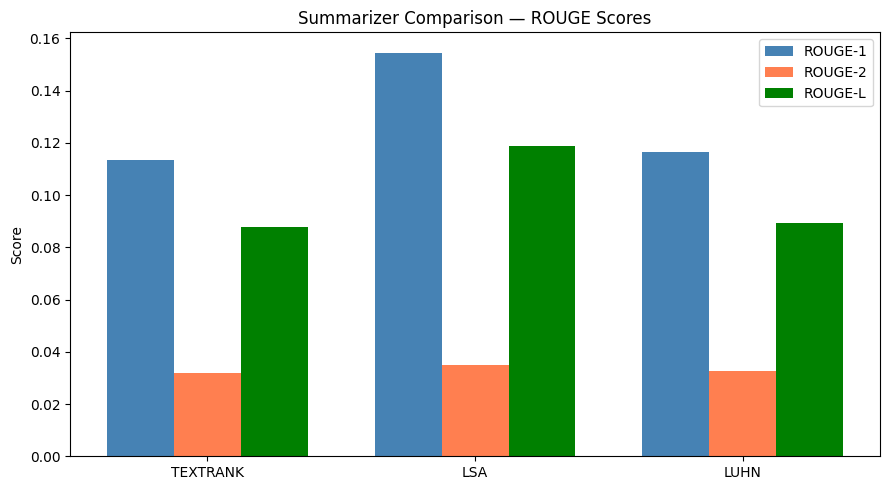

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def evaluate_summarizer(df, summarizer_type='textrank', n_samples=50):
    """Evaluate a summarizer on n_samples from the dataframe."""
    r1, r2, rl = [], [], []
    sample_df = df.head(n_samples)

    for _, row in sample_df.iterrows():
        # Original text as reference (use first 3 sentences as pseudo-reference)
        reference = ' '.join(row['text'].split('.')[:3])
        try:
            hypothesis = summarize_text(row['text'], summarizer_type, 3)
            scores = scorer.score(reference, hypothesis)
            r1.append(scores['rouge1'].fmeasure)
            r2.append(scores['rouge2'].fmeasure)
            rl.append(scores['rougeL'].fmeasure)
        except:
            pass

    return {
        'ROUGE-1': round(sum(r1)/len(r1), 4) if r1 else 0,
        'ROUGE-2': round(sum(r2)/len(r2), 4) if r2 else 0,
        'ROUGE-L': round(sum(rl)/len(rl), 4) if rl else 0
    }

print("Evaluating summarizers (50 samples)...")
results = {}
for method in ['textrank', 'lsa', 'luhn']:
    results[method] = evaluate_summarizer(df_test, method, 50)
    print(f"{method.upper():10s} → {results[method]}")

# Plot ROUGE scores
methods = list(results.keys())
r1_scores = [results[m]['ROUGE-1'] for m in methods]
r2_scores = [results[m]['ROUGE-2'] for m in methods]
rl_scores = [results[m]['ROUGE-L'] for m in methods]

x = range(len(methods))
plt.figure(figsize=(9, 5))
plt.bar([i - 0.25 for i in x], r1_scores, width=0.25, label='ROUGE-1', color='steelblue')
plt.bar([i        for i in x], r2_scores, width=0.25, label='ROUGE-2', color='coral')
plt.bar([i + 0.25 for i in x], rl_scores, width=0.25, label='ROUGE-L', color='green')
plt.xticks(x, [m.upper() for m in methods])
plt.ylabel('Score')
plt.title('Summarizer Comparison — ROUGE Scores')
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 10: Demo — End-to-End Pipeline on a Single Case

This code implements a **complete pipeline** that preprocesses a legal case, predicts the violated articles using the trained classification model, and generates a summary of the case. The text is first cleaned using the preprocessing function and converted into TF-IDF features. The model then predicts the relevant legal articles, and an extractive summary is generated using the selected summarization method.


In [ ]:
def predict_and_summarize(case_text, model=lr_model, summarizer='textrank'):
    """Full pipeline: preprocess → classify → summarize a legal case."""
    print("=" * 65)
    print("⚖️  LEGAL CASE ANALYSIS")
    print("=" * 65)

    # Preprocess
    clean = preprocess_text(case_text)

    # Classify
    vec     = tfidf.transform([clean])
    pred    = model.predict(vec)
    articles = mlb.inverse_transform(pred)[0]

    print("\n📌 PREDICTED VIOLATED ARTICLES:")
    print(" → ", list(articles) if articles else "None predicted")

    # Summarize
    summary = summarize_text(case_text, summarizer, 3)
    print("\n📝 EXTRACTIVE SUMMARY:")
    print(summary)
    print("=" * 65)

# Run on a test case
sample_case = df_test['text'].iloc[2]
predict_and_summarize(sample_case, lr_model, 'textrank')

⚖️  LEGAL CASE ANALYSIS

📌 PREDICTED VIOLATED ARTICLES:
 →  ['6']

📝 EXTRACTIVE SUMMARY:
On 29 March 2013 the Plzeň Regional Court (krajský soud) dismissed a complaint lodged by the applicant against the decision of the Plzeň Regional Office. It held that as the Supreme Administrative Court’s decision had been served on him on 28 August 2013, the last day of the two-month time-limit for lodging a constitutional appeal was 28 October 2013. By a letter of 11 April 2014 the Registrar (generální sekretář) of the Constitutional Court acknowledged that the judge-rapporteur had undoubtedly overlooked the fact that the time-limit had been complied with.


---
## Section 11: Final Summary Table

In [ ]:
summary_data = {
    'Task': ['Classification', 'Classification', 'Classification',
             'Summarization', 'Summarization', 'Summarization'],
    'Model/Method': ['Logistic Regression', 'SVM', 'Naive Bayes',
                     'TextRank', 'LSA', 'Luhn'],
    'Micro F1 / ROUGE-1': [
        round(f1_score(y_test, y_pred_lr,  average='micro'), 4),
        round(f1_score(y_test, y_pred_svm, average='micro'), 4),
        round(f1_score(y_test, y_pred_nb,  average='micro'), 4),
        results['textrank']['ROUGE-1'],
        results['lsa']['ROUGE-1'],
        results['luhn']['ROUGE-1']
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 Final Results Summary")
print(summary_df.to_string(index=False))


📊 Final Results Summary
          Task        Model/Method  Micro F1 / ROUGE-1
Classification Logistic Regression              0.6051
Classification                 SVM              0.6592
Classification         Naive Bayes              0.5583
 Summarization            TextRank              0.1134
 Summarization                 LSA              0.1546
 Summarization                Luhn              0.1166


This code creates a **summary table of the final results** for both classification and summarization tasks. It stores the performance metrics, including **Micro F1 scores for classification models** and **ROUGE-1 scores for summarization methods**. The results are then organized into a pandas DataFrame and displayed as a table for easy comparison.


In [ ]:
summary_data_rows = []

summary_data_rows.append({
    'Task': 'Classification',
    'Model/Method': 'Logistic Regression',
    'Micro F1': round(f1_score(y_test, y_pred_lr, average='micro', zero_division=0), 4),
    'Macro F1': round(f1_score(y_test, y_pred_lr, average='macro', zero_division=0), 4),
    'ROUGE-1': None,
    'ROUGE-2': None,
    'ROUGE-L': None
})
summary_data_rows.append({
    'Task': 'Classification',
    'Model/Method': 'SVM',
    'Micro F1': round(f1_score(y_test, y_pred_svm, average='micro', zero_division=0), 4),
    'Macro F1': round(f1_score(y_test, y_pred_svm, average='macro', zero_division=0), 4),
    'ROUGE-1': None,
    'ROUGE-2': None,
    'ROUGE-L': None
})
summary_data_rows.append({
    'Task': 'Classification',
    'Model/Method': 'SVM Balanced',
    'Micro F1': round(f1_score(y_test, y_pred_bal, average='micro', zero_division=0), 4),
    'Macro F1': round(f1_score(y_test, y_pred_bal, average='macro', zero_division=0), 4),
    'ROUGE-1': None,
    'ROUGE-2': None,
    'ROUGE-L': None
})
summary_data_rows.append({
    'Task': 'Classification',
    'Model/Method': 'Naive Bayes',
    'Micro F1': round(f1_score(y_test, y_pred_nb, average='micro', zero_division=0), 4),
    'Macro F1': round(f1_score(y_test, y_pred_nb, average='macro', zero_division=0), 4),
    'ROUGE-1': None,
    'ROUGE-2': None,
    'ROUGE-L': None
})

summary_data_rows.append({
    'Task': 'Summarization',
    'Model/Method': 'TextRank',
    'Micro F1': None,
    'Macro F1': None,
    'ROUGE-1': results['textrank']['ROUGE-1'],
    'ROUGE-2': results['textrank']['ROUGE-2'],
    'ROUGE-L': results['textrank']['ROUGE-L']
})
summary_data_rows.append({
    'Task': 'Summarization',
    'Model/Method': 'LSA',
    'Micro F1': None,
    'Macro F1': None,
    'ROUGE-1': results['lsa']['ROUGE-1'],
    'ROUGE-2': results['lsa']['ROUGE-2'],
    'ROUGE-L': results['lsa']['ROUGE-L']
})
summary_data_rows.append({
    'Task': 'Summarization',
    'Model/Method': 'Luhn',
    'Micro F1': None,
    'Macro F1': None,
    'ROUGE-1': results['luhn']['ROUGE-1'],
    'ROUGE-2': results['luhn']['ROUGE-2'],
    'ROUGE-L': results['luhn']['ROUGE-L']
})

summary_df = pd.DataFrame(summary_data_rows)
print("\n📊 Final Results Summary")
print(summary_df.to_string(index=False))


📊 Final Results Summary
          Task        Model/Method  Micro F1  Macro F1  ROUGE-1  ROUGE-2  ROUGE-L
Classification Logistic Regression    0.6051    0.1517      NaN      NaN      NaN
Classification                 SVM    0.6592    0.2463      NaN      NaN      NaN
Classification        SVM Balanced    0.6848    0.3371      NaN      NaN      NaN
Classification         Naive Bayes    0.5583    0.1356      NaN      NaN      NaN
 Summarization            TextRank       NaN       NaN   0.1134   0.0320   0.0878
 Summarization                 LSA       NaN       NaN   0.1546   0.0350   0.1188
 Summarization                Luhn       NaN       NaN   0.1166   0.0328   0.0893
